# 10 — Evaluation Scenarios Deep Dive

This notebook provides a comprehensive visual and quantitative analysis of the four C2G-Bench evaluation scenarios.

**Contents**
1. [Setup](#1-setup)
2. [Scenario Parameters Overview](#2-scenario-parameters-overview)
3. [Radar Chart — Multi-Dimensional Stress Profile](#3-radar-chart)
4. [Episode Rollout Traces](#4-episode-rollout-traces) — 2-hour simulated trajectories per scenario
5. [Termination Risk Analysis](#5-termination-risk-analysis)
6. [Cumulative Reward Comparison](#6-cumulative-reward-comparison)
7. [Scenario × Market Configuration Grid](#7-scenario--market-grid)


## 1. Setup

In [1]:
import sys, os
os.chdir("/lustre/guillant/C2G-Macro")
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

from c2g_env.env_low_level import C2GFastEnv

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

SCENARIOS = ["default", "scenario_a", "scenario_b", "scenario_c"]
LABELS    = ["Default\n(Baseline)", "Scenario A\n(GenAI Crisis)", 
             "Scenario B\n(Thermal Squeeze)", "Scenario C\n(Battery Drain)"]
SHORT     = ["Default", "GenAI Crisis", "Thermal Squeeze", "Battery Drain"]
COLORS    = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
MARKERS   = ["o", "s", "^", "D"]

# Collect scenario configs
envs_cfg = {}
for s in SCENARIOS:
    e = C2GFastEnv(scenario=s)
    envs_cfg[s] = {"scfg": dict(e._scfg), "rcfg": dict(e._rcfg)}
    e.close()

print("Scenario configs loaded:")
for s, d in envs_cfg.items():
    sc = d["scfg"]
    print(f"  {s:12s}  T_amb={sc['T_amb']}°C  MW={sc['committed_mw']}  "
          f"SOC0={sc['bess_soc_init']:.0%}  genai={sc['genai_spike_scale']}x  "
          f"stress={sc['grid_stress_scale']}x  fault={sc['cooling_fault']}")


Scenario configs loaded:
  default       T_amb=25.0°C  MW=15.0  SOC0=50%  genai=1.0x  stress=1.0x  fault=False
  scenario_a    T_amb=30.0°C  MW=20.0  SOC0=55%  genai=1.8x  stress=1.5x  fault=False
  scenario_b    T_amb=40.0°C  MW=30.0  SOC0=60%  genai=1.0x  stress=1.3x  fault=False
  scenario_c    T_amb=32.0°C  MW=20.0  SOC0=15%  genai=1.2x  stress=1.2x  fault=True


## 2. Scenario Parameters Overview

Side-by-side bar charts of the key configurable parameters across all four scenarios.


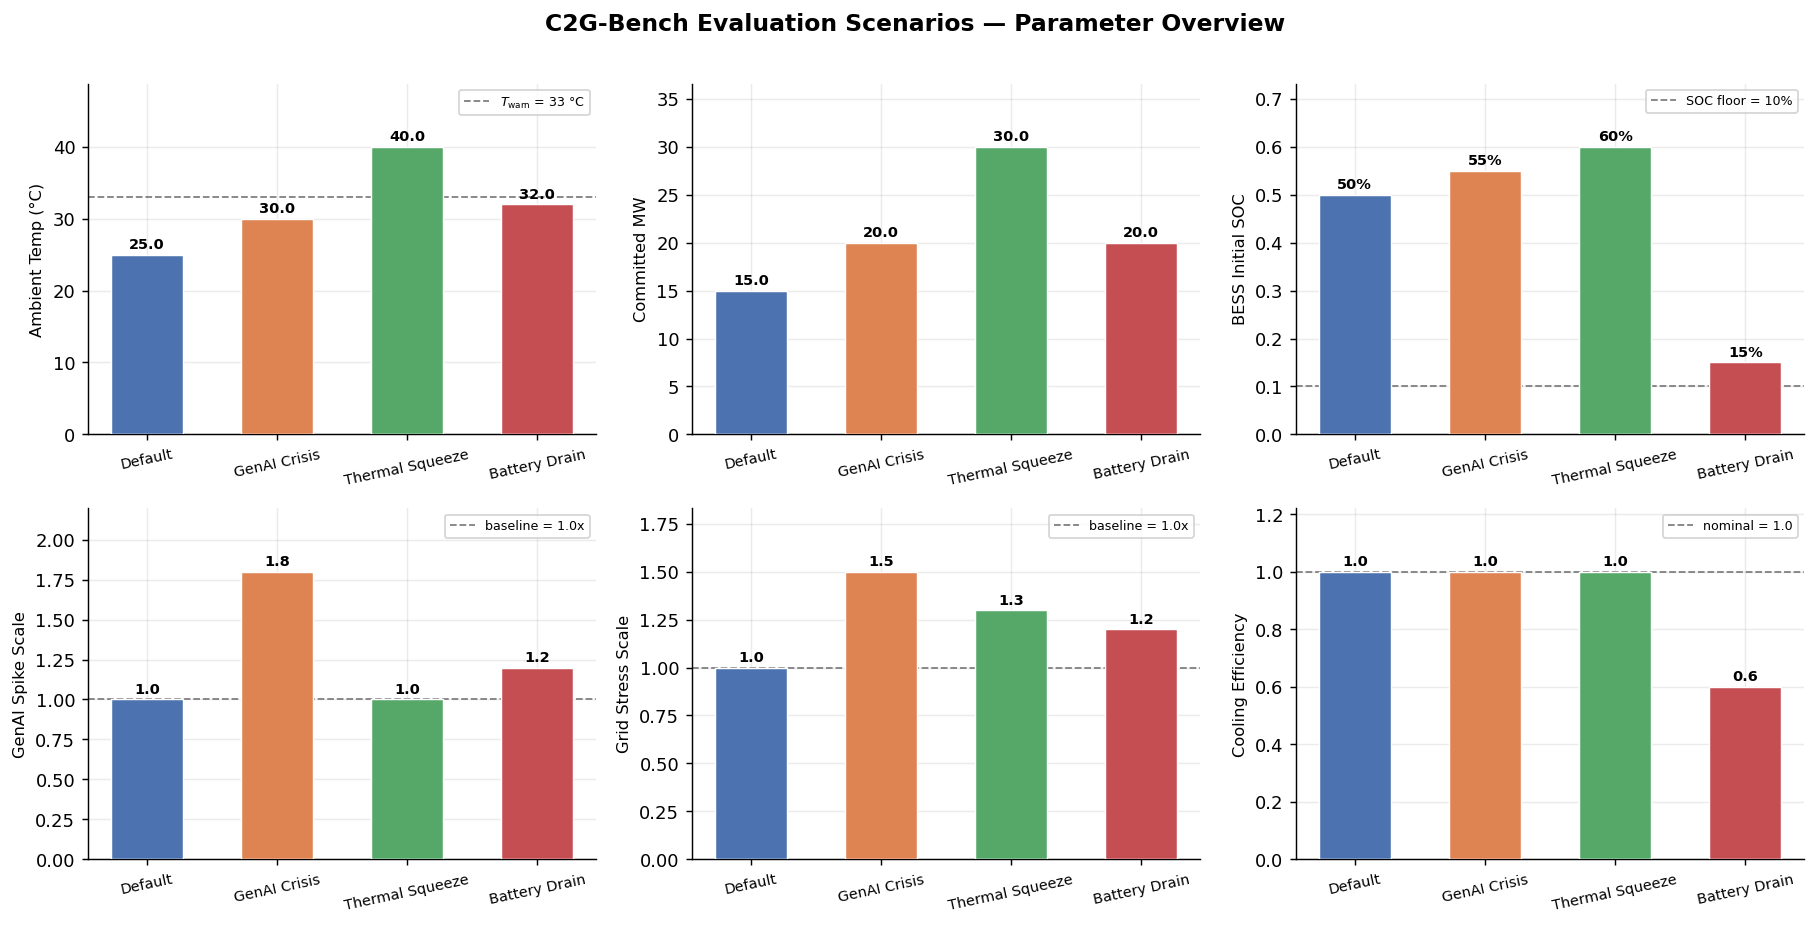

Saved fig_scenarios_params.png


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("C2G-Bench Evaluation Scenarios — Parameter Overview", fontsize=13, fontweight="bold", y=1.01)

params = [
    ("T_amb",              "Ambient Temp (°C)",          [25, 30, 40, 32],      "red",       [33, 33, 33, 33],   "$T_{\mathrm{warn}}$ = 33 °C"),
    ("committed_mw",       "Committed MW",                [15, 20, 30, 20],      "steelblue", None,               None),
    ("bess_soc_init",      "BESS Initial SOC",            [0.50,0.55,0.60,0.15], "green",     [0.10,0.10,0.10,0.10], "SOC floor = 10%"),
    ("genai_spike_scale",  "GenAI Spike Scale",           [1.0, 1.8, 1.0, 1.2], "purple",    [1.0,1.0,1.0,1.0], "baseline = 1.0x"),
    ("grid_stress_scale",  "Grid Stress Scale",           [1.0, 1.5, 1.3, 1.2], "darkorange",[1.0,1.0,1.0,1.0], "baseline = 1.0x"),
    ("cooling_fault_factor","Cooling Efficiency",         [1.0, 1.0, 1.0, 0.6], "brown",     [1.0,1.0,1.0,1.0], "nominal = 1.0"),
]

x = np.arange(4)
for ax, (key, ylabel, vals, color, ref, ref_label) in zip(axes.flat, params):
    bars = ax.bar(x, vals, color=[COLORS[i] for i in range(4)], width=0.55, zorder=3, edgecolor="white", linewidth=0.8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(SHORT, fontsize=8, rotation=12)
    # Value labels
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(vals),
                f"{v:.0%}" if key=="bess_soc_init" else f"{v:.1f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")
    # Reference line
    if ref:
        ax.axhline(ref[0], color="gray", linestyle="--", linewidth=1, label=ref_label)
        ax.legend(fontsize=7, loc="upper right")
    ax.set_ylim(0, max(vals) * 1.22)

plt.tight_layout()
plt.savefig("fig_scenarios_params.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved fig_scenarios_params.png")


## 3. Radar Chart — Multi-Dimensional Stress Profile

A spider/radar chart normalising each stress dimension to [0, 1] shows the *overall challenge profile* of each scenario at a glance.


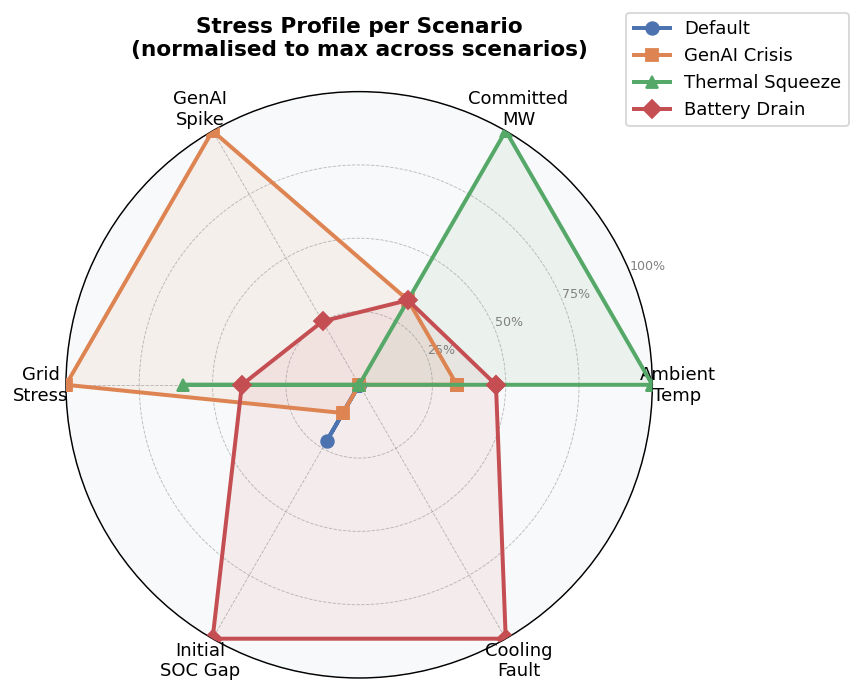

Saved fig_scenarios_radar.png


In [3]:
# Normalise all axes to [0,1] relative to their max stress
axes_labels = [
    "Ambient\nTemp", "Committed\nMW", "GenAI\nSpike",
    "Grid\nStress", "Initial\nSOC Gap", "Cooling\nFault"
]

# Raw values per scenario  [default, scenario_a, scenario_b, scenario_c]
raw = np.array([
    [25,  30,  40,  32 ],   # T_amb (higher = more stress)
    [15,  20,  30,  20 ],   # committed_mw
    [1.0, 1.8, 1.0, 1.2],   # genai_spike_scale
    [1.0, 1.5, 1.3, 1.2],   # grid_stress_scale
    [0.5, 0.45,0.4, 0.85],  # distance from 1.0 SOC (1-soc_init = SOC gap)
    [0.0, 0.0, 0.0, 0.4 ],  # cooling fault severity (1 - efficiency)
], dtype=float)

# Normalise each row to [0,1]
raw_min = raw.min(axis=1, keepdims=True)
raw_max = raw.max(axis=1, keepdims=True)
norm = (raw - raw_min) / np.where(raw_max - raw_min == 0, 1, raw_max - raw_min)

N_axes = len(axes_labels)
angles = np.linspace(0, 2*np.pi, N_axes, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("white")

for i, (scenario, label, color) in enumerate(zip(SCENARIOS, SHORT, COLORS)):
    values = norm[:, i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2.2, marker=MARKERS[i], markersize=7, label=label, zorder=5)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(axes_labels, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7, color="gray")
ax.set_ylim(0, 1)
ax.set_title("Stress Profile per Scenario\n(normalised to max across scenarios)", 
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)

# Concentric grid styling
ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("fig_scenarios_radar.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved fig_scenarios_radar.png")


## 4. Episode Rollout Traces

Simulated 2-hour (1,440 × 5 s) trajectories using a fixed *conservative action* (30% throttle, 60% pump, 60% HVAC, 0% BESS) to isolate the effect of scenario parameters on the physics.

The dashed horizontal lines mark key safety thresholds:
- **Red dashed** — hard limit ($T_\text{safe}$ = 35 °C, SOC floor/ceil, |Δf| = 0.5 Hz, $V < 0.90$ pu)
- **Orange dashed** — soft warning ($T_\text{warn}$ = 33 °C)


In [ ]:
N_TICKS = 1440  # 2 hours
SEED    = 42
ACT     = np.array([0.30, 0.60, 0.60, 0.00])  # conservative, no BESS

traces = {}
for s in SCENARIOS:
    env = C2GFastEnv(scenario=s)
    obs, _ = env.reset(seed=SEED)
    rec = {k: [] for k in ["temp_A","temp_B","bess_soc","f_grid_hz",
                             "v_pcc_pu","reward","regd_signal",
                             "tracking_err_kw","p_facility_mw"]}
    terminated = None
    for t in range(N_TICKS):
        obs, rew, term, trunc, info = env.step(ACT)
        for k in rec:
            rec[k].append(info.get(k, np.nan))
        if term or trunc:
            terminated = t
            break
    for k in rec:
        rec[k] = np.array(rec[k])
    traces[s] = {"rec": rec, "terminated": terminated}
    env.close()
    tstr = f"terminated at tick {terminated}" if terminated is not None else f"survived all {N_TICKS} ticks"
    print(f"  {s:12s}: {tstr}")

time_min = np.arange(N_TICKS) * 5 / 60  # minutes
print("\nRollouts complete.")


  default     : survived all 1440 ticks


  scenario_a  : survived all 1440 ticks


  scenario_b  : survived all 1440 ticks


  scenario_c  : survived all 1440 ticks

Rollouts complete.


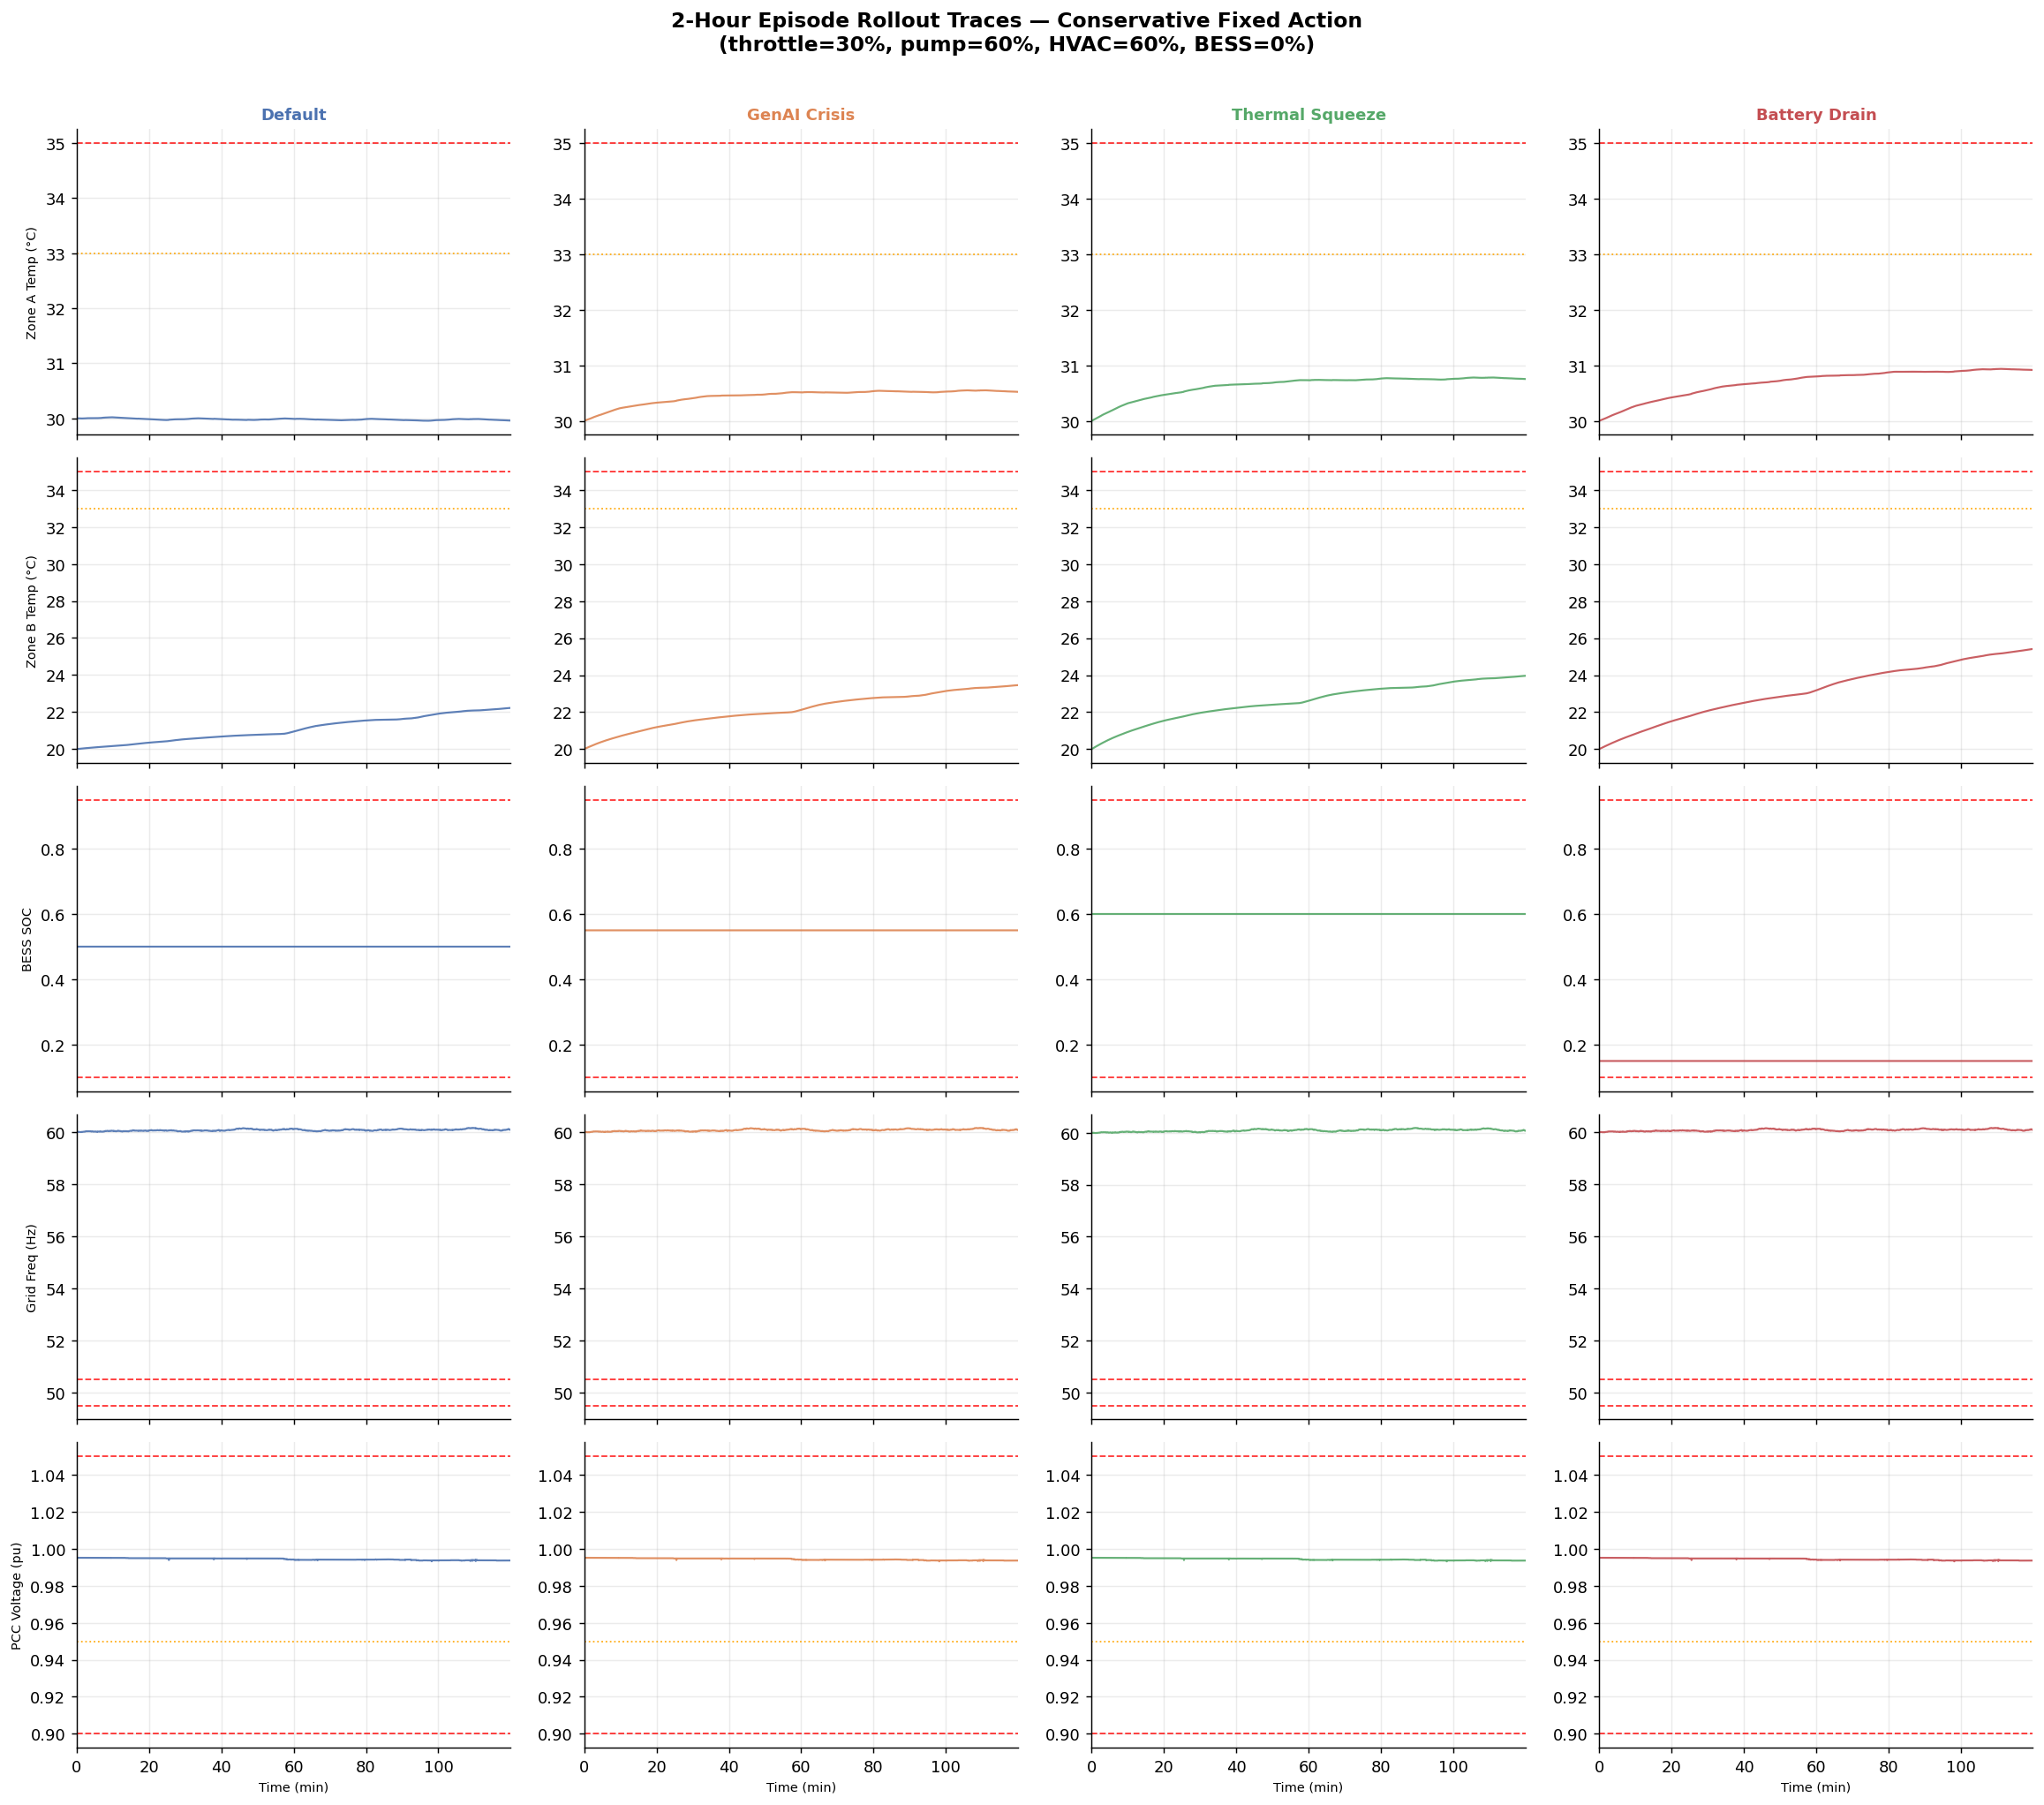

Saved fig_scenarios_rollouts.png


In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(18, 16), sharex=True)
fig.suptitle("2-Hour Episode Rollout Traces — Conservative Fixed Action\n"
             "(throttle=30%, pump=60%, HVAC=60%, BESS=0%)",
             fontsize=13, fontweight="bold")

row_labels = [
    "Zone A Temp (°C)",
    "Zone B Temp (°C)",
    "BESS SOC",
    "Grid Freq (Hz)",
    "PCC Voltage (pu)",
]
row_keys  = ["temp_A", "temp_B", "bess_soc", "f_grid_hz", "v_pcc_pu"]
row_hard  = [35.0,    35.0,    None,     50.5,    0.90]
row_warn  = [33.0,    33.0,    None,     None,    0.95]
row_hard2 = [None,    None,    [0.10,0.95], 49.5, 1.05]  # second hard line (BESS, over-freq, over-volt)

for col, (s, label, color) in enumerate(zip(SCENARIOS, SHORT, COLORS)):
    rec = traces[s]["rec"]
    terminated = traces[s]["terminated"]
    T = len(rec["temp_A"])
    t = time_min[:T]

    for row, (key, ylabel, hard, warn, hard2) in enumerate(
            zip(row_keys, row_labels, row_hard, row_warn, row_hard2)):
        ax = axes[row, col]
        ax.plot(t, rec[key], color=color, linewidth=1.2, alpha=0.9)

        # Hard limits
        if hard is not None:
            ax.axhline(hard, color="red", linestyle="--", linewidth=1.0, alpha=0.8, label=f"Hard={hard}")
        if isinstance(hard2, list):
            for h in hard2:
                ax.axhline(h, color="red", linestyle="--", linewidth=1.0, alpha=0.8)
        elif hard2 is not None:
            ax.axhline(hard2, color="red", linestyle="--", linewidth=1.0, alpha=0.8)

        # Soft warning
        if warn is not None:
            ax.axhline(warn, color="orange", linestyle=":", linewidth=1.0, alpha=0.9)

        if col == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        if row == 0:
            ax.set_title(label, fontsize=10, fontweight="bold", color=color)
        if row == 4:
            ax.set_xlabel("Time (min)", fontsize=8)

        # Shading above/below limit
        if key == "temp_A":
            ax.fill_between(t, rec[key], 33.0, where=(rec[key] > 33.0),
                            alpha=0.15, color="orange", label="Warn zone")
            ax.fill_between(t, rec[key], 35.0, where=(rec[key] > 35.0),
                            alpha=0.25, color="red")

        # Termination marker
        if terminated is not None and terminated < N_TICKS:
            ax.axvline(time_min[terminated], color="black", linestyle="-", linewidth=1.5, alpha=0.6)

ax.set_xlim(0, time_min[N_TICKS-1])
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("fig_scenarios_rollouts.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved fig_scenarios_rollouts.png")


## 5. Termination Risk Analysis

We run 30 episodes per scenario with **random actions** (uniform in action space) and record the tick at which the episode terminates. Earlier termination = more difficult scenario.


In [6]:
N_EPISODES = 30
N_MAX      = 500   # cap at 500 ticks (~42 min) for speed

termination_ticks = {s: [] for s in SCENARIOS}

for s in SCENARIOS:
    for ep in range(N_EPISODES):
        env = C2GFastEnv(scenario=s)
        obs, _ = env.reset(seed=ep)
        for t in range(N_MAX):
            act = env.action_space.sample()
            obs, _, term, trunc, _ = env.step(act)
            if term or trunc:
                termination_ticks[s].append(t + 1)
                break
        else:
            termination_ticks[s].append(N_MAX)  # survived
        env.close()
    arr = np.array(termination_ticks[s])
    print(f"{s:12s}  median={np.median(arr):5.0f}  mean={arr.mean():5.0f}  "
          f"min={arr.min()}  survived_full={( arr==N_MAX).sum()}/{N_EPISODES}")

print("\nDone.")


default       median=  500  mean=  500  min=500  survived_full=30/30


scenario_a    median=  500  mean=  500  min=500  survived_full=30/30


scenario_b    median=  500  mean=  500  min=500  survived_full=30/30


scenario_c    median=  500  mean=  500  min=500  survived_full=30/30

Done.


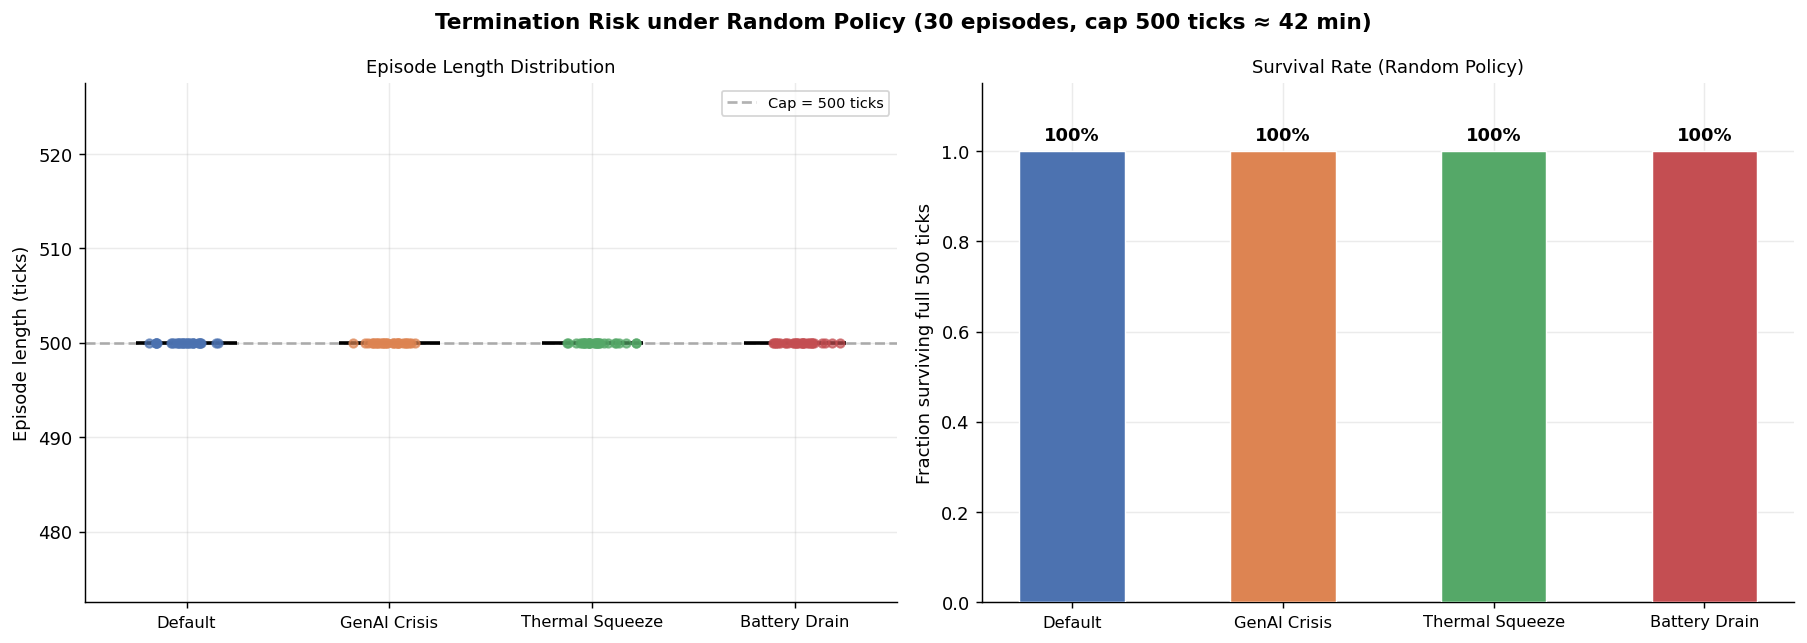

Saved fig_scenarios_termination.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Termination Risk under Random Policy (30 episodes, cap 500 ticks ≈ 42 min)",
             fontsize=12, fontweight="bold")

# Left: box + strip plot
ax = axes[0]
data = [termination_ticks[s] for s in SCENARIOS]
bp = ax.boxplot(data, patch_artist=True, notch=False, widths=0.5,
                medianprops={"color":"black","linewidth":2})
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
for i, (s, color) in enumerate(zip(SCENARIOS, COLORS)):
    y = termination_ticks[s]
    x = np.random.normal(i+1, 0.08, size=len(y))
    ax.scatter(x, y, color=color, s=22, alpha=0.7, zorder=5)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(SHORT, fontsize=9)
ax.set_ylabel("Episode length (ticks)", fontsize=10)
ax.set_title("Episode Length Distribution", fontsize=10)
ax.axhline(N_MAX, color="gray", linestyle="--", alpha=0.6, label=f"Cap = {N_MAX} ticks")
ax.legend(fontsize=8)

# Right: survival fraction bar
ax2 = axes[1]
survive_frac = [np.mean(np.array(termination_ticks[s]) == N_MAX) for s in SCENARIOS]
bars = ax2.bar(SHORT, survive_frac, color=COLORS, width=0.5, edgecolor="white", linewidth=0.8, zorder=3)
for bar, v in zip(bars, survive_frac):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.015, f"{v:.0%}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("Fraction surviving full 500 ticks", fontsize=10)
ax2.set_title("Survival Rate (Random Policy)", fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.set_xticklabels(SHORT, fontsize=9)

plt.tight_layout()
plt.savefig("fig_scenarios_termination.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved fig_scenarios_termination.png")


## 6. Cumulative Reward Comparison

Same conservative fixed action across all scenarios. The reward gap between scenarios quantifies the *inherent difficulty penalty* imposed by the scenario parameters alone, before any training.


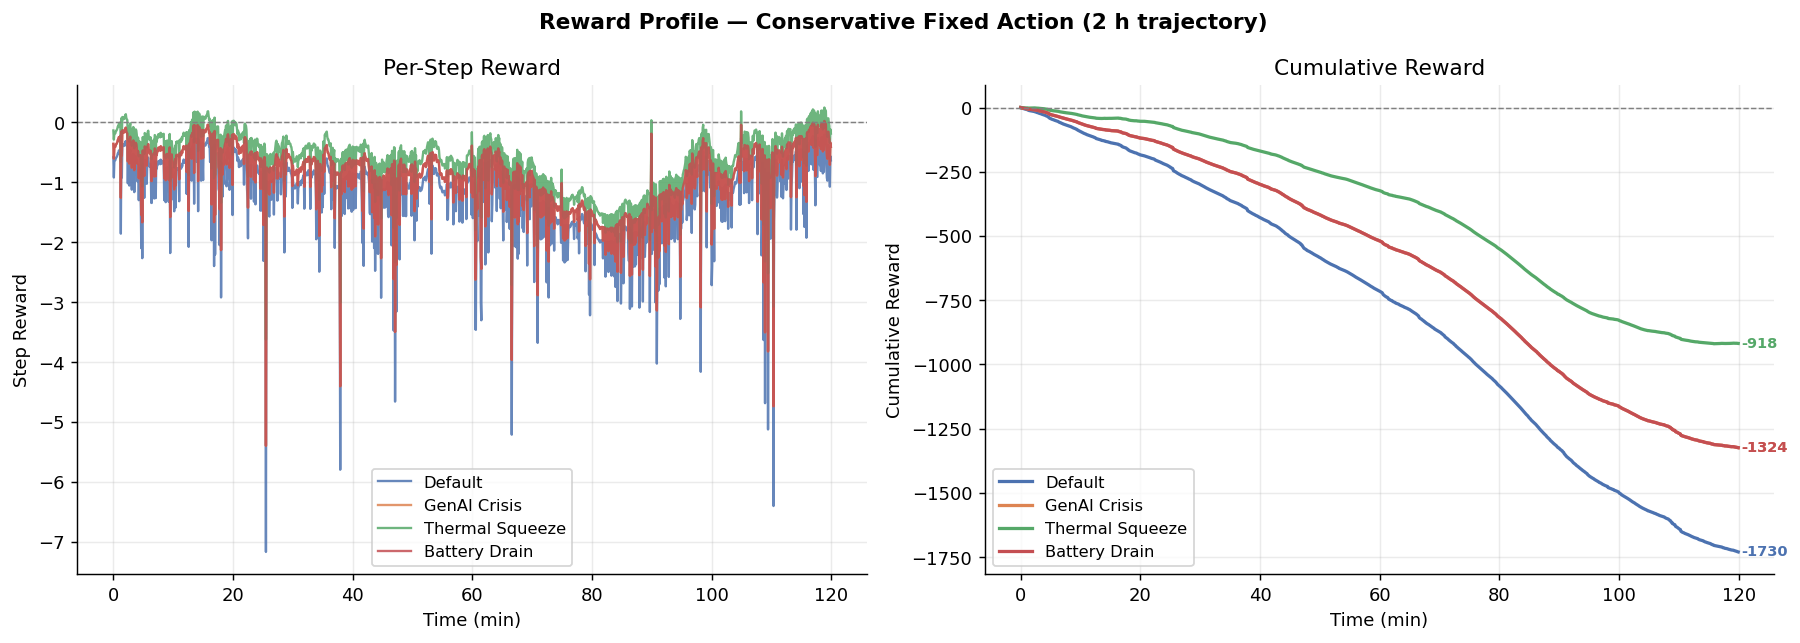

Saved fig_scenarios_reward.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Reward Profile — Conservative Fixed Action (2 h trajectory)", fontsize=12, fontweight="bold")

# Left: per-tick reward
ax = axes[0]
for s, label, color in zip(SCENARIOS, SHORT, COLORS):
    rec = traces[s]["rec"]
    T = len(rec["reward"])
    ax.plot(time_min[:T], rec["reward"], color=color, linewidth=1.3, label=label, alpha=0.85)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Time (min)")
ax.set_ylabel("Step Reward")
ax.set_title("Per-Step Reward")
ax.legend(fontsize=9)

# Right: cumulative reward
ax2 = axes[1]
for s, label, color in zip(SCENARIOS, SHORT, COLORS):
    rec = traces[s]["rec"]
    T = len(rec["reward"])
    cumrew = np.cumsum(rec["reward"])
    ax2.plot(time_min[:T], cumrew, color=color, linewidth=1.8, label=label)
    ax2.text(time_min[T-1] + 0.5, cumrew[-1], f"{cumrew[-1]:.0f}",
             fontsize=8, color=color, va="center", fontweight="bold")
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Time (min)")
ax2.set_ylabel("Cumulative Reward")
ax2.set_title("Cumulative Reward")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_scenarios_reward.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved fig_scenarios_reward.png")


## 7. Scenario × Market Configuration Grid

All **24 evaluation configurations** available in C2G-Bench. ★ marks the default market pairing for each scenario.


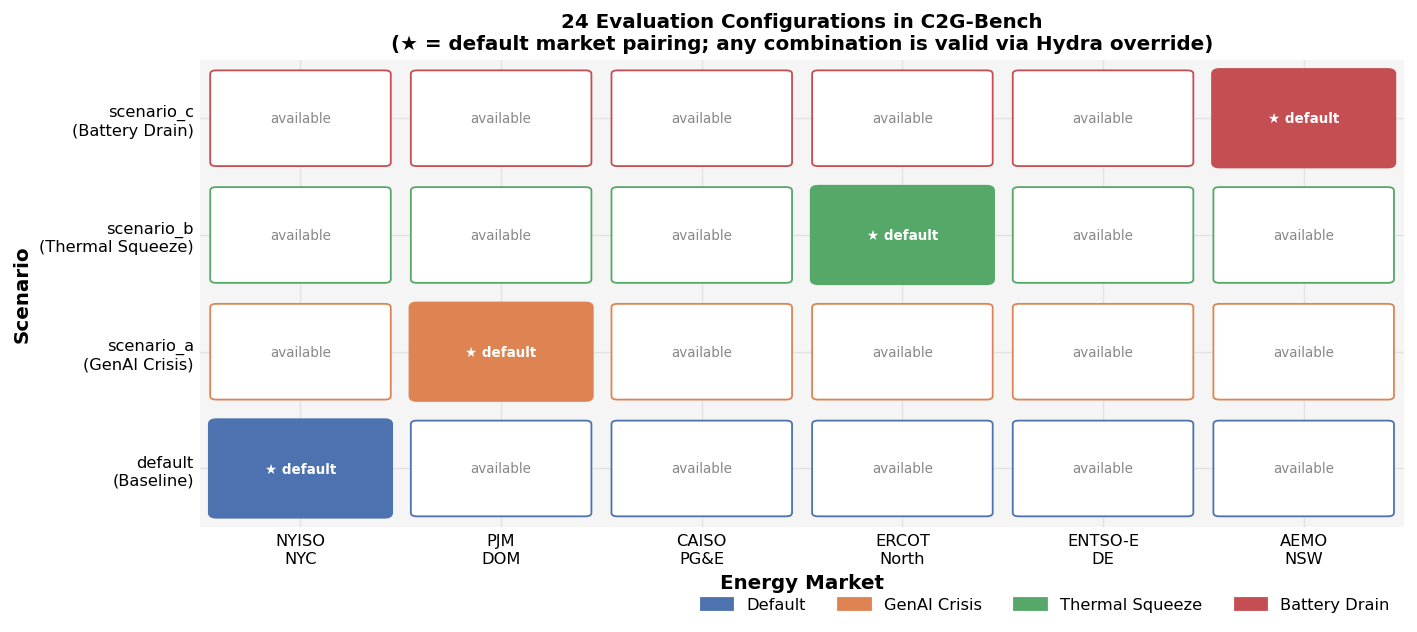

Saved fig_scenarios_market_grid.png


In [9]:
markets  = ["nyiso_nyc", "pjm_dom", "caiso_pgae", "ercot_north", "entso_de", "aemo_nsw"]
mkt_lbls = ["NYISO\nNYC", "PJM\nDOM", "CAISO\nPG&E", "ERCOT\nNorth", "ENTSO-E\nDE", "AEMO\nNSW"]
scen_lbls = ["default\n(Baseline)", "scenario_a\n(GenAI Crisis)",
             "scenario_b\n(Thermal Squeeze)", "scenario_c\n(Battery Drain)"]

# Default market for each scenario
defaults = {"default":"nyiso_nyc","scenario_a":"pjm_dom",
            "scenario_b":"ercot_north","scenario_c":"aemo_nsw"}

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor("#f5f5f5")
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 3.5)

for r, (s, slbl) in enumerate(zip(SCENARIOS, scen_lbls)):
    for c, (m, mlbl) in enumerate(zip(markets, mkt_lbls)):
        is_default = defaults[s] == m
        color = COLORS[r] if is_default else "white"
        edgecolor = COLORS[r]
        lw = 2.5 if is_default else 1.0

        rect = FancyBboxPatch((c - 0.42, r - 0.38), 0.84, 0.76,
                               boxstyle="round,pad=0.03",
                               facecolor=color, edgecolor=edgecolor,
                               linewidth=lw, zorder=3)
        ax.add_patch(rect)

        label = "★ default" if is_default else "available"
        txt_color = "white" if is_default else "#888888"
        weight = "bold" if is_default else "normal"
        ax.text(c, r, label, ha="center", va="center",
                fontsize=7.5, color=txt_color, fontweight=weight, zorder=4)

ax.set_xticks(range(6))
ax.set_xticklabels(mkt_lbls, fontsize=9)
ax.set_yticks(range(4))
ax.set_yticklabels(scen_lbls, fontsize=9)
ax.set_xlabel("Energy Market", fontsize=11, fontweight="bold")
ax.set_ylabel("Scenario", fontsize=11, fontweight="bold")
ax.set_title("24 Evaluation Configurations in C2G-Bench\n"
             "(★ = default market pairing; any combination is valid via Hydra override)",
             fontsize=11, fontweight="bold")
ax.tick_params(length=0)
ax.spines[:].set_visible(False)

legend_patches = [mpatches.Patch(facecolor=c, edgecolor=c, label=s)
                  for c, s in zip(COLORS, SHORT)]
ax.legend(handles=legend_patches, loc="upper right", bbox_to_anchor=(1.0, -0.12),
          ncol=4, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("fig_scenarios_market_grid.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved fig_scenarios_market_grid.png")


## 8. Summary

| Scenario | Market | T_amb | Committed MW | BESS SOC₀ | GenAI Scale | Stress Scale | Cooling Fault | Difficulty |
|----------|--------|-------|-------------|-----------|-------------|-------------|---------------|------------|
| `default` | NYISO NYC | 25 °C | 15 MW | 50% | 1.0× | 1.0× | None | ⭐ |
| `scenario_a` | PJM DOM | 30 °C | 20 MW | 55% | **1.8×** | 1.5× | None | ⭐⭐⭐ |
| `scenario_b` | ERCOT North | **40 °C** | **30 MW** | 60% | 1.0× | 1.3× | None | ⭐⭐⭐⭐ |
| `scenario_c` | AEMO NSW | 32 °C | 20 MW | **15%** | 1.2× | 1.2× | Pump 60% | ⭐⭐⭐⭐⭐ |

Run any configuration with:
```bash
uv run python baselines/train_ppo.py scenario=<name> market=<market_key> experiment.seed=<N>
```
